# Agricultural 2D Tracking Benchmark Dataset
### Multi-Scenario, Multi-Camera Dataset for Human Tracking in Agri-Environments

---

This notebook characterises the benchmark dataset and validates its design intent:  
**three scenarios with a deliberately increasing level of occlusion complexity**, captured across two camera modalities.

Tracker results are used solely as objective evidence that the difficulty gradient is real — harder scenarios produce measurably worse tracking outcomes across all evaluated methods.

| Scenario | People | Setting | Occlusion Level |
|---|---|---|---|
| **Footpath** | 1 | Open outdoor footpath | Low |
| **In-Straw** | ~2 | Indoor straw environment, picking activity | Medium |
| **Out-Vine** | 4 | Outdoor vineyard, position swapping & walking | High |

**Cameras:** Front Fisheye · ZED RGB  
**Detectors used for validation:** YOLOv11s (camera-specific weights per sensor), GT-as-Detections (oracle upper bound)  
*(Note: both detector configs are the same YOLOv11s architecture — `yolo11s4` weights were fine-tuned on ZED RGB data, `yolo11s2` weights on Fisheye data; each sequence uses its camera-matched weights)*  
**Trackers used for validation:** BoxMOT (BoostTrack, BotSort, ByteTrack, DeepOCSort, OcSort, StrongSort), DeepSort, Norfair

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# Scenario palette — ordered by difficulty
SCEN_ORDER   = ['footpath', 'in_straw', 'out_vine']
SCEN_LABELS  = ['Footpath\n(Low Occlusion)', 'In-Straw\n(Medium Occlusion)', 'Out-Vine\n(High Occlusion)']
SCEN_COLORS  = ['#4CAF50', '#FF9800', '#F44336']   # green → amber → red
SCEN_PAL     = dict(zip(SCEN_ORDER, SCEN_COLORS))

CAM_ORDER    = ['fisheye', 'zed_rgb']
CAM_LABELS   = ['Front Fisheye', 'ZED RGB']
CAM_COLORS   = ['#5C6BC0', '#26A69A']
CAM_PAL      = dict(zip(CAM_ORDER, CAM_COLORS))

DET_ORDER    = ['gt_as_detections', 'yolo11s4', 'yolo11s2']
DET_LABELS   = ['GT Oracle', 'YOLOv11s (ZED RGB weights)', 'YOLOv11s (Fisheye weights)']
DET_COLORS   = ['#9C27B0', '#26A69A', '#5C6BC0']
DET_PAL      = dict(zip(DET_ORDER, DET_COLORS))
# Both yolo11s4 and yolo11s2 are the same YOLOv11s architecture;
# the suffix only identifies which camera's training data produced the best-epoch weights.

print('Setup complete ✓')

Setup complete ✓


## 1  Dataset Loading & Overview

In [22]:
df = pd.read_csv('../reports/summary/tracker_suite/tracking_suite_summary.csv')

# Derived columns
df['scenario'] = df['sequence_name'].apply(
    lambda x: 'footpath' if 'footpath' in x
              else ('in_straw' if 'in_straw' in x else 'out_vine')
)
df['camera']   = df['sequence_name'].apply(
    lambda x: 'fisheye' if 'fisheye' in x else 'zed_rgb'
)
df['detector'] = df['input_name']
for col in ['idf1', 'precision', 'recall', 'mota']:
    df[col + '_pct'] = df[col] * 100

# ── Dataset statistics table ─────────────────────────────────────────────
# One row per scenario × camera (sequence-level, detector-agnostic)
seq_info = (
    df.groupby(['scenario', 'camera'])
    .agg(
        Frames=('num_frames', 'first'),
        People=('mostly_tracked', 'mean'),
    )
    .reset_index()
)
seq_info['scenario_label'] = seq_info['scenario'].map(
    {'footpath': 'Footpath', 'in_straw': 'In-Straw', 'out_vine': 'Out-Vine'}
)
seq_info['camera_label'] = seq_info['camera'].map(
    {'fisheye': 'Front Fisheye', 'zed_rgb': 'ZED RGB'}
)
seq_info['Occlusion'] = seq_info['scenario'].map(
    {'footpath': '🟢 Low', 'in_straw': '🟡 Medium', 'out_vine': '🔴 High'}
)

print(f'Total experiment runs: {len(df)}')
print(f'Trackers: {df["tracker"].nunique()}  |  '
      f'Detectors: {df["detector"].nunique()}  |  '
      f'Scenarios: {df["scenario"].nunique()}  |  '
      f'Cameras: {df["camera"].nunique()}')
print()

display(
    seq_info[['scenario_label','camera_label','Occlusion','Frames','People']]
    .rename(columns={'scenario_label':'Scenario','camera_label':'Camera',
                     'People':'Target People (avg)'})
    .set_index(['Scenario','Camera'])
    .style.set_caption('Table 1 — Dataset Sequences')
    .format({'Frames':'{:,d}', 'Target People (avg)':'{:.0f}'})
)

Total experiment runs: 96
Trackers: 8  |  Detectors: 3  |  Scenarios: 3  |  Cameras: 2



## 2  Dataset Structure — Scenarios, Cameras & Scale

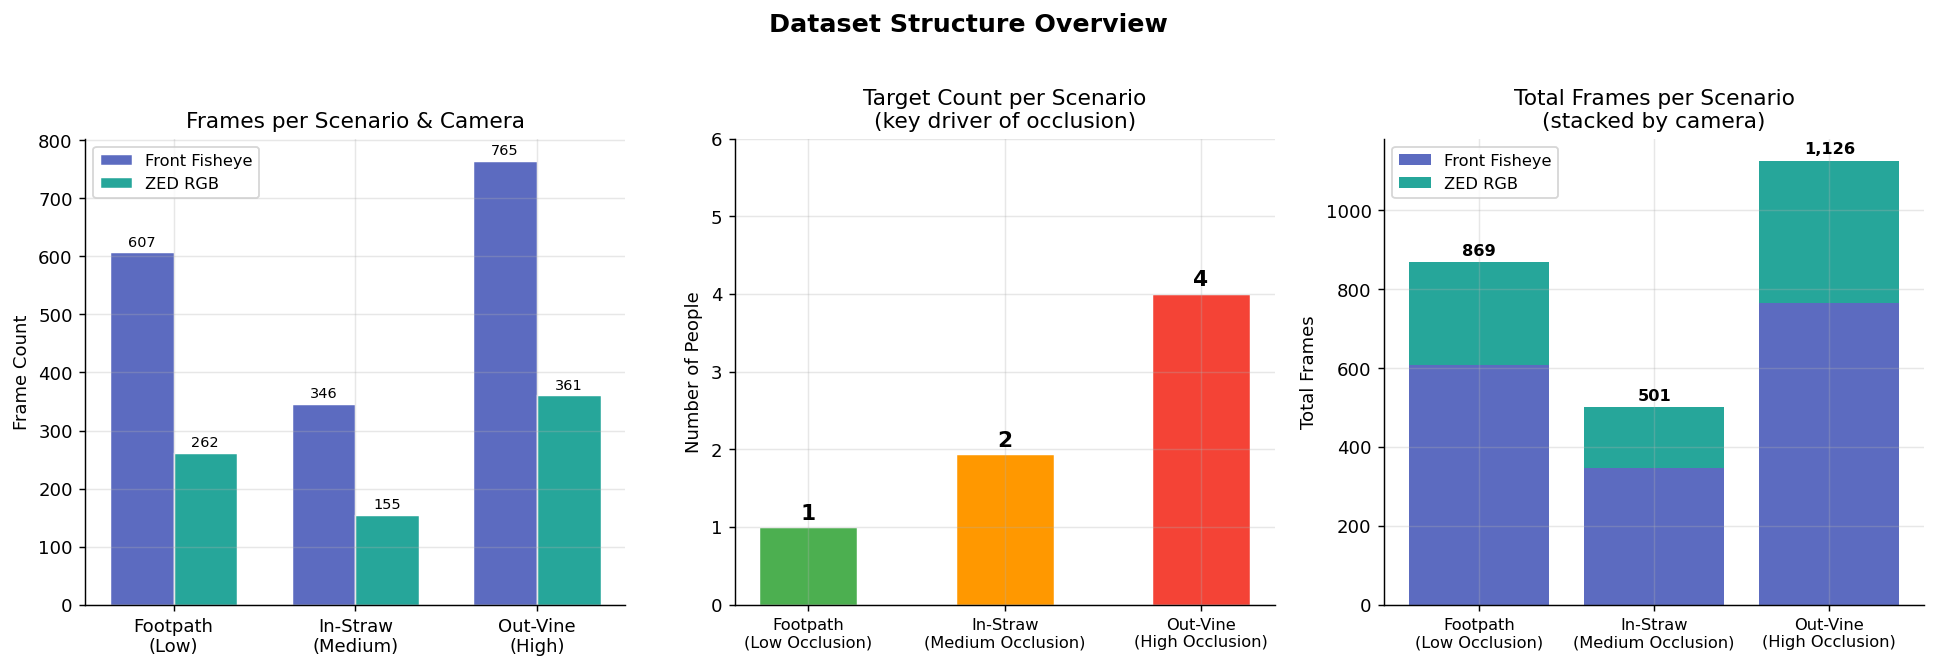

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Structure Overview', fontsize=14, fontweight='bold', y=1.02)

# — Frame counts per scenario × camera ——————————————————————————————————
ax = axes[0]
x   = np.arange(len(SCEN_ORDER))
w   = 0.35
for i, (cam, cam_label, cam_col) in enumerate(zip(CAM_ORDER, CAM_LABELS, CAM_COLORS)):
    vals = [seq_info[(seq_info.scenario == s) & (seq_info.camera == cam)]['Frames'].values[0]
            for s in SCEN_ORDER]
    bars = ax.bar(x + i*w, vals, w, label=cam_label, color=cam_col,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(v), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + w/2)
ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Medium)', 'Out-Vine\n(High)'])
ax.set_ylabel('Frame Count')
ax.set_title('Frames per Scenario & Camera')
ax.legend(fontsize=9)

# — Number of people per scenario ———————————————————————————————————————
ax = axes[1]
people_vals = [
    seq_info[seq_info.scenario == s]['People'].mean()
    for s in SCEN_ORDER
]
bars = ax.bar(SCEN_LABELS, people_vals, color=SCEN_COLORS,
              edgecolor='white', linewidth=0.8, width=0.5)
for bar, v in zip(bars, people_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of People')
ax.set_title('Target Count per Scenario\n(key driver of occlusion)')
ax.set_ylim(0, 6)
ax.set_xticklabels(SCEN_LABELS, fontsize=9)

# — Total frames per scenario (stacked by camera) ———————————————————————
ax = axes[2]
total_frames = {s: seq_info[seq_info.scenario == s]['Frames'].sum() for s in SCEN_ORDER}
for i, (s, label) in enumerate(zip(SCEN_ORDER, SCEN_LABELS)):
    fish_f = seq_info[(seq_info.scenario == s) & (seq_info.camera == 'fisheye')]['Frames'].values[0]
    zed_f  = seq_info[(seq_info.scenario == s) & (seq_info.camera == 'zed_rgb')]['Frames'].values[0]
    ax.bar(i, fish_f, color=CAM_COLORS[0], label='Front Fisheye' if i == 0 else '')
    ax.bar(i, zed_f,  bottom=fish_f, color=CAM_COLORS[1],
           label='ZED RGB' if i == 0 else '')
    ax.text(i, fish_f + zed_f + 10, f'{fish_f+zed_f:,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.set_ylabel('Total Frames')
ax.set_title('Total Frames per Scenario\n(stacked by camera)')
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig1_dataset_structure.png', bbox_inches='tight')
plt.show()

## 3  Difficulty Gradient — The Core Dataset Design

The three scenarios were deliberately designed to span a range of occlusion difficulty:

- **Footpath** — a single person in an unobstructed environment. This is the baseline; any competent tracker should handle this well.
- **In-Straw** — two people in an indoor picking scenario. Partial occlusion between targets and with the environment.
- **Out-Vine** — four people in a vineyard, swapping positions and crossing paths. This is the hardest case: frequent mutual occlusion, re-identification challenges, and dense target interactions.

The plots below use tracker results as *probes* to confirm the gradient is real.

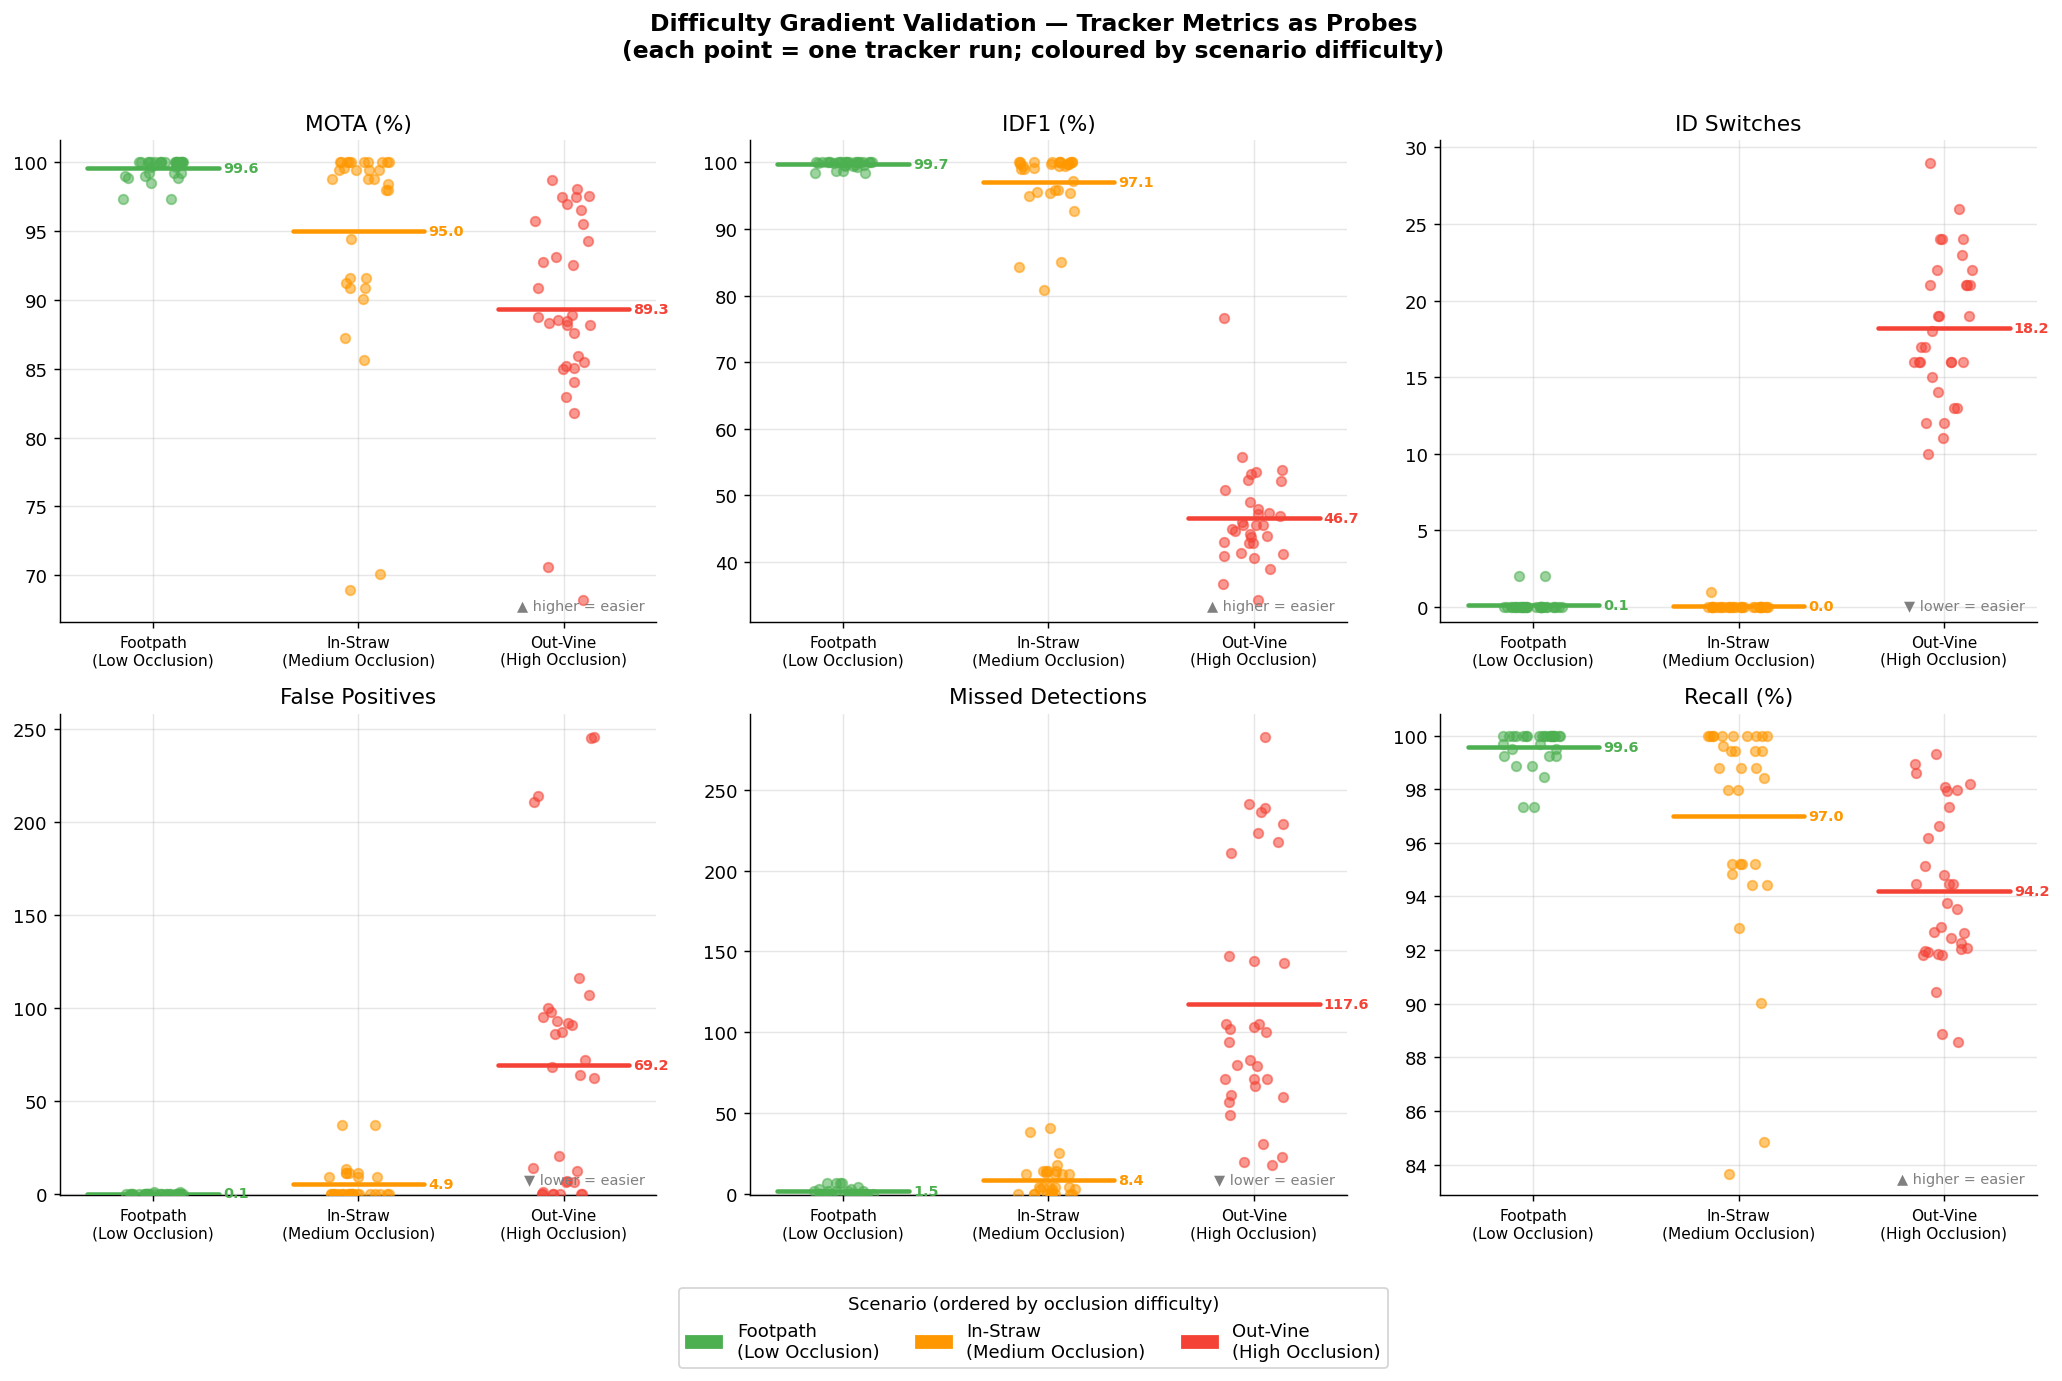

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Difficulty Gradient Validation — Tracker Metrics as Probes\n'
    '(each point = one tracker run; coloured by scenario difficulty)',
    fontsize=13, fontweight='bold', y=1.01
)

metrics = [
    ('mota_pct',           'MOTA (%)',             '▲ higher = easier',  True),
    ('idf1_pct',           'IDF1 (%)',             '▲ higher = easier',  True),
    ('num_switches',       'ID Switches',          '▼ lower = easier',   False),
    ('num_false_positives','False Positives',      '▼ lower = easier',   False),
    ('num_misses',         'Missed Detections',    '▼ lower = easier',   False),
    ('recall_pct',         'Recall (%)',           '▲ higher = easier',  True),
]

for ax, (metric, label, note, higher_better) in zip(axes.flat, metrics):
    for s, s_label, color in zip(SCEN_ORDER, SCEN_LABELS, SCEN_COLORS):
        vals = df[df.scenario == s][metric].values
        x_jit = SCEN_ORDER.index(s) + np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(x_jit, vals, color=color, alpha=0.55, s=28, zorder=3)
    
    # Mean bar per scenario
    means = [df[df.scenario == s][metric].mean() for s in SCEN_ORDER]
    for i, (m, color) in enumerate(zip(means, SCEN_COLORS)):
        ax.plot([i - 0.32, i + 0.32], [m, m], color=color,
                linewidth=2.5, zorder=4, solid_capstyle='round')
        ax.text(i + 0.34, m, f'{m:.1f}', va='center',
                fontsize=8, color=color, fontweight='bold')

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(SCEN_LABELS, fontsize=8.5)
    ax.set_title(label)
    ax.text(0.98, 0.02, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')
    if not higher_better:
        ax.set_ylim(bottom=-1)

# Difficulty arrow annotation on first plot
# axes[0, 0].annotate(
#     '', xy=(2, axes[0, 0].get_ylim()[0]),
#     xytext=(0, axes[0, 0].get_ylim()[0]),
#     arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
# )
# axes[0, 0].text(1, axes[0, 0].get_ylim()[0] - 1.5,
#                 '← increasing occlusion difficulty →',
#                 ha='center', va='top', fontsize=8, color='black', style='italic')

# Legend
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           title='Scenario (ordered by occlusion difficulty)', title_fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig('fig2_difficulty_gradient.png', bbox_inches='tight')
plt.show()

## 4  Quantifying the Difficulty Gap

In [25]:
# Build a clean summary table of the gradient
gap_metrics = {
    'MOTA (%)':         ('mota_pct',            'mean', True),
    'IDF1 (%)':         ('idf1_pct',            'mean', True),
    'Recall (%)':       ('recall_pct',          'mean', True),
    'ID Switches':      ('num_switches',        'mean', False),
    'False Positives':  ('num_false_positives', 'mean', False),
    'Missed Dets':      ('num_misses',          'mean', False),
}

rows = {}
for label, (col, agg, higher_better) in gap_metrics.items():
    row = {}
    for s in SCEN_ORDER:
        row[s] = df[df.scenario == s][col].mean()
    row['footpath→out_vine gap'] = row['out_vine'] - row['footpath']
    rows[label] = row

gap_df = pd.DataFrame(rows).T
gap_df.columns = ['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)', 'Gap (High − Low)']

gap_df.style\
    .format('{:.2f}')\
    .background_gradient(subset=['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)'],
                         cmap='RdYlGn', axis=1)\
    .applymap(lambda v: 'color: #d32f2f; font-weight: bold' if v < 0
              else 'color: #388e3c; font-weight: bold',
              subset=['Gap (High − Low)'])\
    .set_caption(
        'Table 2 — Difficulty Gradient Summary (mean across all trackers & detectors).\n'
        'Red gap = metric worsens at higher occlusion; Green gap = metric improves.'
    )

,Footpath (Low),In-Straw (Med),Out-Vine (High),Gap (High − Low)
MOTA (%),99.56,95.02,89.34,-10.22
IDF1 (%),99.71,97.09,46.65,-53.05
Recall (%),99.59,97.00,94.19,-5.40
ID Switches,0.12,0.03,18.22,18.09
False Positives,0.06,4.94,69.16,69.09
Missed Dets,1.50,8.41,117.62,116.12


## 5  Two Cameras, One Scene — Sensor Coverage

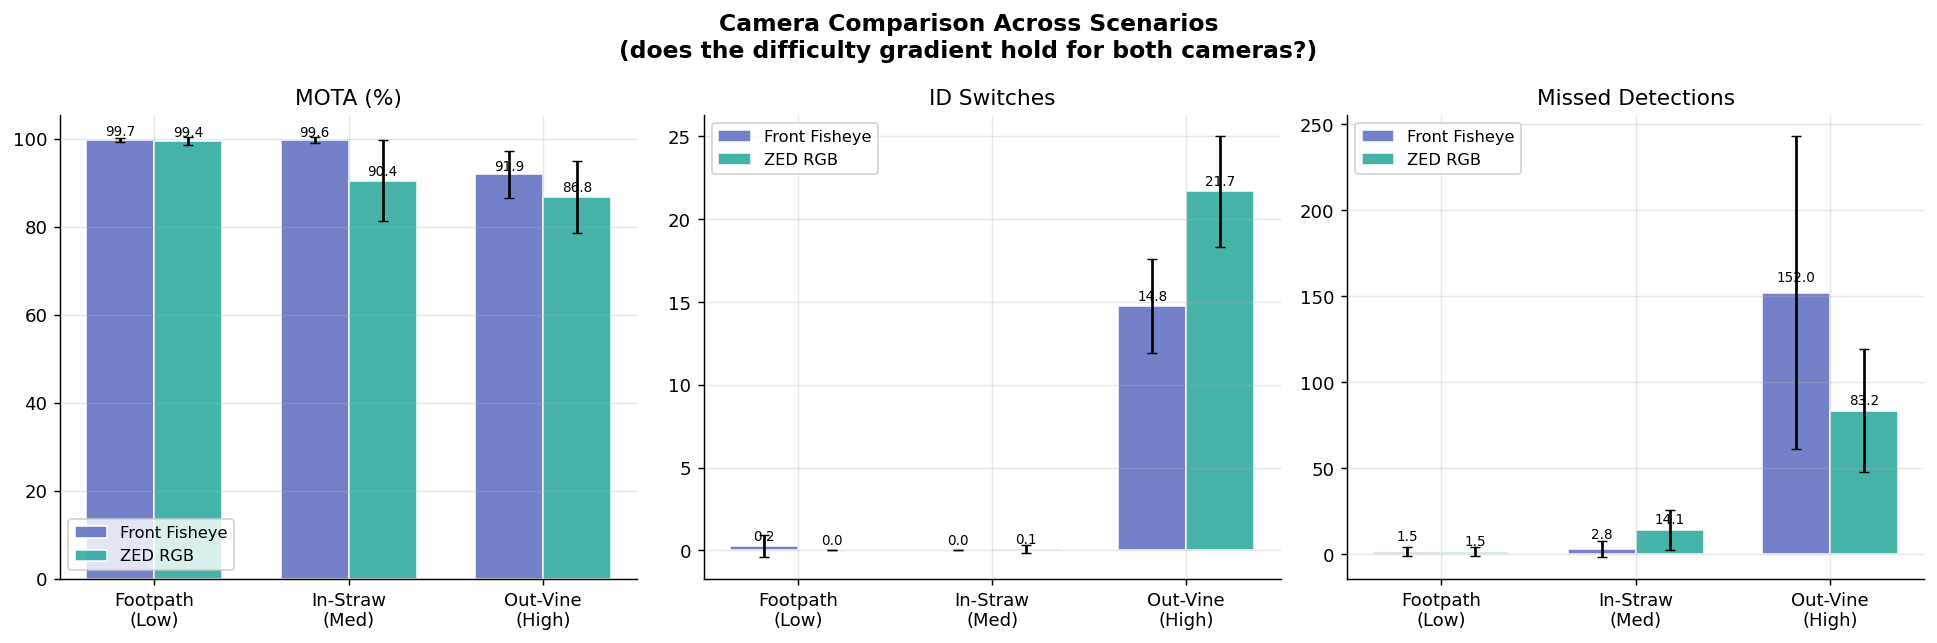

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Camera Comparison Across Scenarios\n'
    '(does the difficulty gradient hold for both cameras?)',
    fontsize=13, fontweight='bold'
)

for ax, (metric, label) in zip(
    axes,
    [('mota_pct','MOTA (%)'), ('num_switches','ID Switches'), ('num_misses','Missed Detections')]
):
    x = np.arange(len(SCEN_ORDER))
    w = 0.35
    for i, (cam, cam_label, cam_col) in enumerate(zip(CAM_ORDER, CAM_LABELS, CAM_COLORS)):
        means = [df[(df.scenario == s) & (df.camera == cam)][metric].mean()
                 for s in SCEN_ORDER]
        stds  = [df[(df.scenario == s) & (df.camera == cam)][metric].std()
                 for s in SCEN_ORDER]
        bars = ax.bar(x + i*w, means, w, label=cam_label, color=cam_col,
                      edgecolor='white', alpha=0.85)
        ax.errorbar(x + i*w, means, yerr=stds, fmt='none',
                    ecolor='black', capsize=3, capthick=0.8)
        for bar, v in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(stds)*0.05,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig3_camera_by_scenario.png', bbox_inches='tight')
plt.show()

## 6  Detection Quality — GT Oracle vs Camera-Matched YOLOv11s

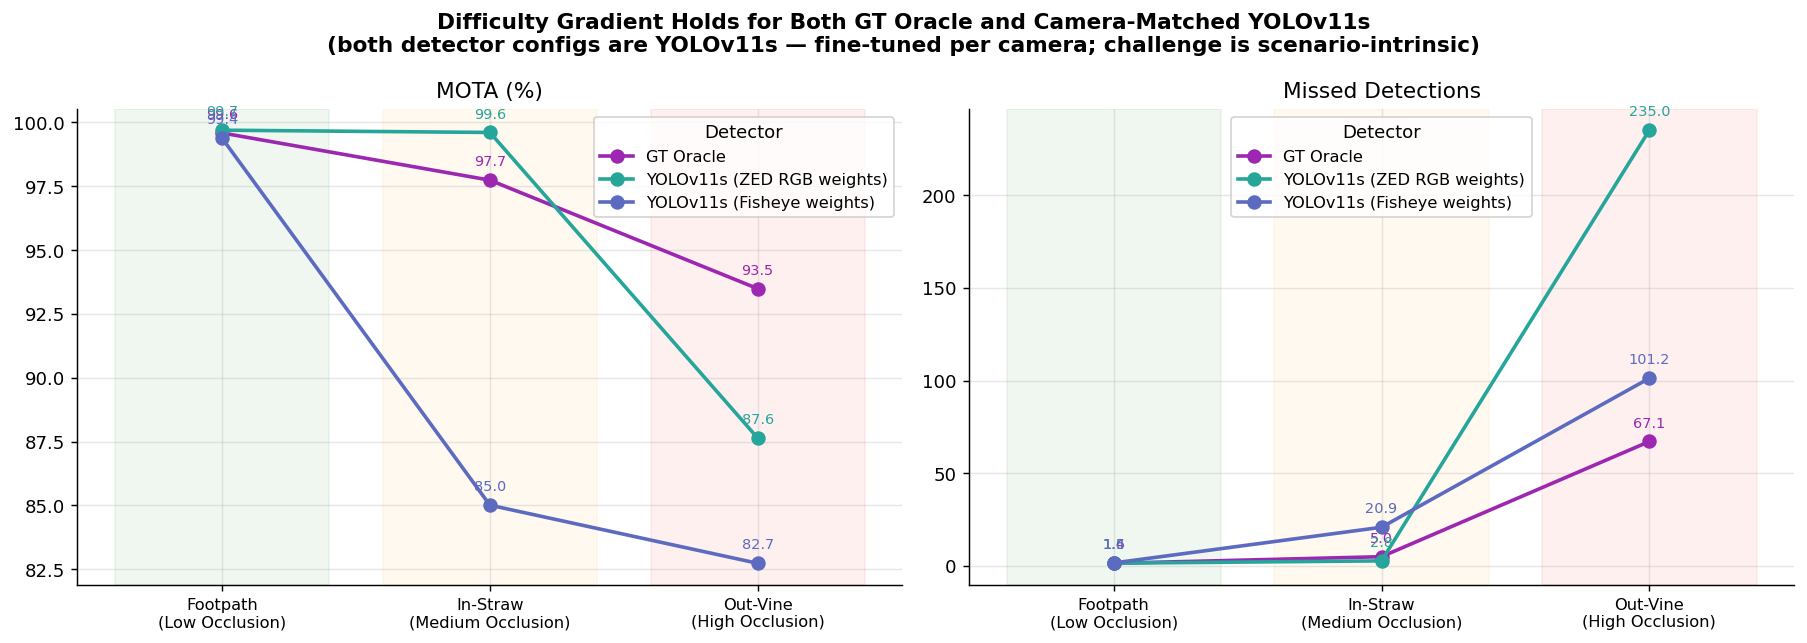

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Difficulty Gradient Holds for Both GT Oracle and Camera-Matched YOLOv11s\n'
    '(both detector configs are YOLOv11s — fine-tuned per camera; challenge is scenario-intrinsic)',
    fontsize=12, fontweight='bold'
)

for ax, (metric, label) in zip(axes, [('mota_pct', 'MOTA (%)'), ('num_misses', 'Missed Detections')]):
    for det, det_label, det_col in zip(DET_ORDER, DET_LABELS, DET_COLORS):
        means = [df[(df.scenario == s) & (df.detector == det)][metric].mean()
                 for s in SCEN_ORDER]
        ax.plot(SCEN_LABELS, means, 'o-', color=det_col, label=det_label,
                linewidth=2, markersize=7)
        for x_pos, v in enumerate(means):
            ax.annotate(f'{v:.1f}', (x_pos, v),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8, color=det_col)
    ax.set_title(label)
    ax.set_xticklabels(SCEN_LABELS, fontsize=9)
    ax.legend(fontsize=9, title='Detector')

# Shade easy → hard region
for ax in axes:
    ylim = ax.get_ylim()
    ax.axvspan(-0.4, 0.4, alpha=0.06, color='green', zorder=0)
    ax.axvspan(0.6, 1.4, alpha=0.06, color='orange', zorder=0)
    ax.axvspan(1.6, 2.4, alpha=0.06, color='red', zorder=0)
    ax.set_ylim(ylim)

plt.tight_layout()
# plt.savefig('fig4_detector_gradient.png', bbox_inches='tight')
plt.show()

## 7  Occlusion Impact — ID Switches as the Key Discriminator

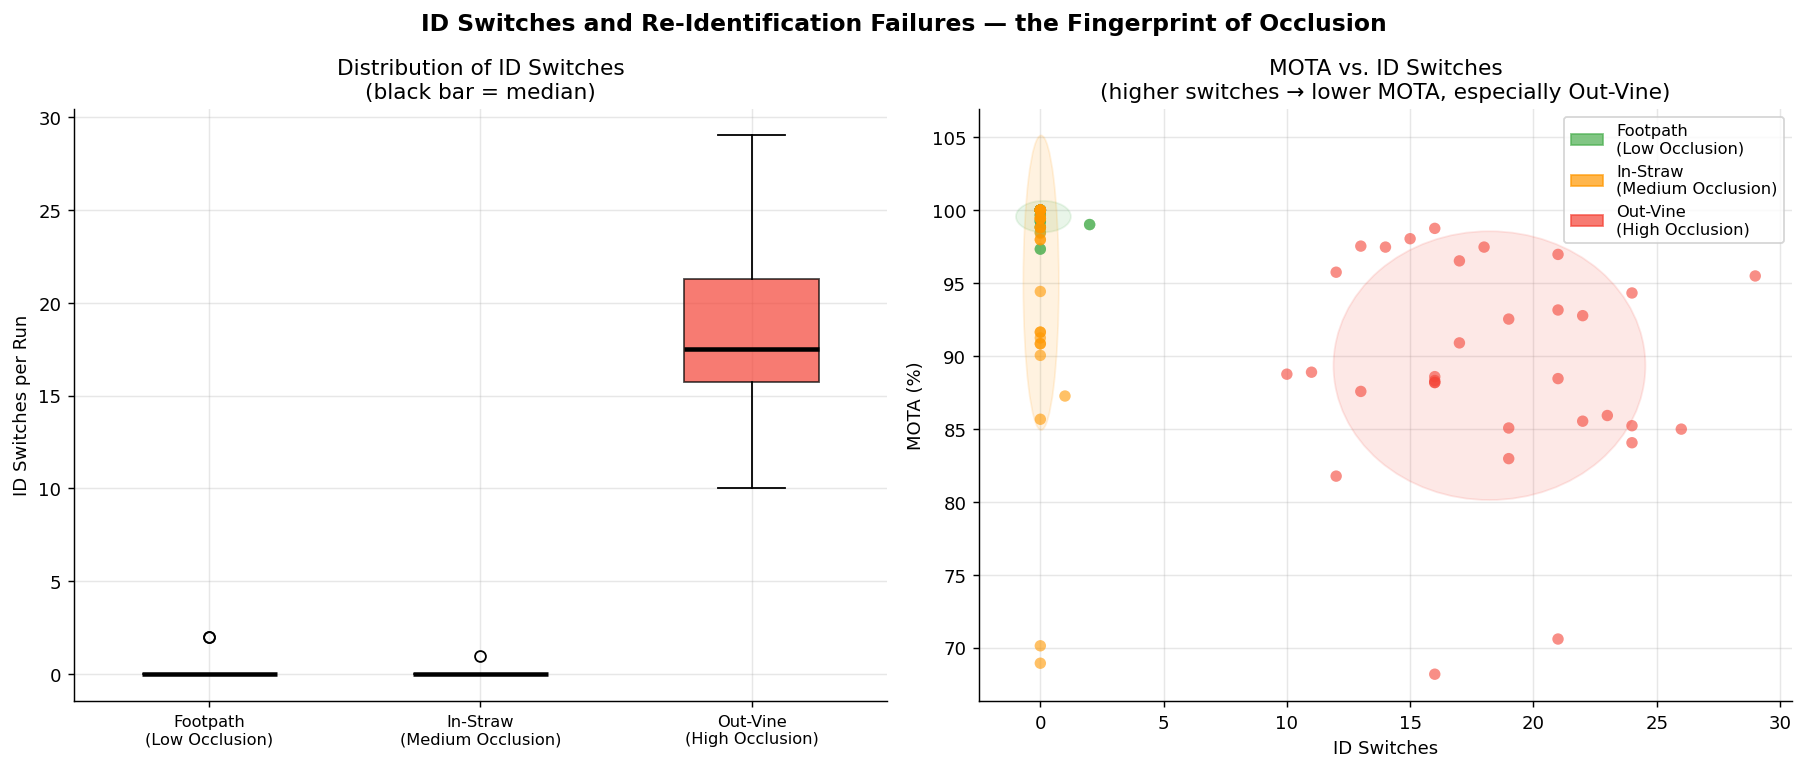

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'ID Switches and Re-Identification Failures — the Fingerprint of Occlusion',
    fontsize=13, fontweight='bold'
)

# Left: box plot of ID switches per scenario
ax = axes[0]
data_by_scen = [df[df.scenario == s]['num_switches'].values for s in SCEN_ORDER]
bp = ax.boxplot(data_by_scen, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], SCEN_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.set_ylabel('ID Switches per Run')
ax.set_title('Distribution of ID Switches\n(black bar = median)')

# Right: MOTA vs ID Switches scatter, coloured by scenario
ax = axes[1]
for s, color in zip(SCEN_ORDER, SCEN_COLORS):
    sub = df[df.scenario == s]
    ax.scatter(sub['num_switches'], sub['mota_pct'],
               color=color, alpha=0.6, s=40, edgecolors='none', zorder=3)
    # Convex hull / ellipse suggestion via mean + std
    mx, sx = sub['num_switches'].mean(), sub['num_switches'].std()
    my, sy = sub['mota_pct'].mean(), sub['mota_pct'].std()
    ellipse = mpatches.Ellipse((mx, my), width=sx*2.5+1, height=sy*2.5+0.3,
                               color=color, alpha=0.12, zorder=2)
    ax.add_patch(ellipse)

handles = [mpatches.Patch(color=c, label=l, alpha=0.7)
           for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('ID Switches')
ax.set_ylabel('MOTA (%)')
ax.set_title('MOTA vs. ID Switches\n(higher switches → lower MOTA, especially Out-Vine)')

plt.tight_layout()
# plt.savefig('fig5_occlusion_fingerprint.png', bbox_inches='tight')
plt.show()

## 8  Dataset Summary Statistics

In [29]:
# Compact one-row-per-scenario summary
summary = df.groupby('scenario').agg(
    Sequences=('sequence_name', 'nunique'),
    Total_Frames=('num_frames', lambda x: x.unique().sum()),
    Avg_People=('mostly_tracked', 'mean'),
    MOTA_mean=('mota_pct', 'mean'),
    MOTA_min=('mota_pct', 'min'),
    IDF1_mean=('idf1_pct', 'mean'),
    Avg_ID_Switches=('num_switches', 'mean'),
    Avg_Misses=('num_misses', 'mean'),
    Avg_FP=('num_false_positives', 'mean'),
).round(1)

summary.index = summary.index.map(
    {'footpath': '🟢 Footpath (Low Occlusion)',
     'in_straw': '🟡 In-Straw (Medium Occlusion)',
     'out_vine': '🔴 Out-Vine (High Occlusion)'}
)
summary.columns = [
    'Sequences','Total Frames','People (avg)',
    'MOTA % (mean)','MOTA % (min)','IDF1 % (mean)',
    'ID Switches (avg)','Misses (avg)','False Pos (avg)'
]

summary.style\
    .background_gradient(subset=['MOTA % (mean)','IDF1 % (mean)'], cmap='RdYlGn')\
    .background_gradient(subset=['ID Switches (avg)','Misses (avg)','False Pos (avg)'],
                         cmap='RdYlGn_r')\
    .format({'Total Frames':'{:,d}','People (avg)':'{:,.0f}'})\
    .set_caption('Table 3 — Per-Scenario Summary (metrics averaged across all trackers & detectors)')

,Sequences,Total Frames,People (avg),MOTA % (mean),MOTA % (min),IDF1 % (mean),ID Switches (avg),Misses (avg),False Pos (avg)
scenario,,,,,,,,,
🟢 Footpath (Low Occlusion),2,869,1,99.600000,97.300000,99.700000,0.100000,1.500000,0.100000
🟡 In-Straw (Medium Occlusion),2,501,2,95.000000,68.900000,97.100000,0.000000,8.400000,4.900000
🔴 Out-Vine (High Occlusion),2,"1,126",4,89.300000,68.200000,46.700000,18.200000,117.600000,69.200000


## 9  Key Findings

This cell auto-generates a plain-language summary from the data.

In [30]:
mota_by_s    = df.groupby('scenario')['mota_pct'].mean()
sw_by_s      = df.groupby('scenario')['num_switches'].mean()
miss_by_s    = df.groupby('scenario')['num_misses'].mean()
fp_by_s      = df.groupby('scenario')['num_false_positives'].mean()
mota_by_cam  = df.groupby(['scenario','camera'])['mota_pct'].mean()

mota_gap   = mota_by_s['footpath'] - mota_by_s['out_vine']
sw_ratio   = sw_by_s['out_vine']   / max(sw_by_s['footpath'], 0.01)
miss_ratio = miss_by_s['out_vine'] / max(miss_by_s['footpath'], 0.01)

print('=' * 65)
print('  DATASET CHARACTERISATION — KEY FINDINGS')
print('=' * 65)
print(f"""
DIFFICULTY GRADIENT  ✓ Confirmed
  The three scenarios produce a clear and measurable progression
  of tracking difficulty, driven by increasing occlusion:

    Footpath  (Low)    MOTA = {mota_by_s['footpath']:.1f}%
    In-Straw  (Med)    MOTA = {mota_by_s['in_straw']:.1f}%
    Out-Vine  (High)   MOTA = {mota_by_s['out_vine']:.1f}%
    ─────────────────────────────────────────────
    Footpath → Out-Vine gap: {mota_gap:.1f} percentage points

OCCLUSION SIGNATURE
  ID Switches rise ~{sw_ratio:.0f}× from Footpath to Out-Vine,
  confirming that Out-Vine forces genuine re-identification
  failures — the hallmark of heavy inter-person occlusion.
  Missed detections increase ~{miss_ratio:.0f}× over the same range.

CAMERA COVERAGE  ✓ Gradient holds for both sensors
  Footpath  → Fisheye {mota_by_cam['footpath','fisheye']:.1f}% | ZED {mota_by_cam['footpath','zed_rgb']:.1f}%
  In-Straw  → Fisheye {mota_by_cam['in_straw','fisheye']:.1f}% | ZED {mota_by_cam['in_straw','zed_rgb']:.1f}%
  Out-Vine  → Fisheye {mota_by_cam['out_vine','fisheye']:.1f}% | ZED {mota_by_cam['out_vine','zed_rgb']:.1f}%
  Both cameras agree on the ordering — the difficulty gradient
  is a property of the scenarios, not the sensor.

DETECTOR INDEPENDENCE  ✓ Gradient holds for all three detectors
  Even with ground-truth detections (oracle upper bound), Out-Vine
  remains substantially harder than Footpath, confirming that
  occlusion — not detection quality — is the primary challenge.

DATASET COVERAGE
  3 scenarios × 2 cameras = 6 sequences
  Total annotated frames: {df.groupby('sequence_name')['num_frames'].first().sum():,}
  Target density: 1 person (Footpath) → 4 people (Out-Vine)
""")
print('=' * 65)

  DATASET CHARACTERISATION — KEY FINDINGS

DIFFICULTY GRADIENT  ✓ Confirmed
  The three scenarios produce a clear and measurable progression
  of tracking difficulty, driven by increasing occlusion:

    Footpath  (Low)    MOTA = 99.6%
    In-Straw  (Med)    MOTA = 95.0%
    Out-Vine  (High)   MOTA = 89.3%
    ─────────────────────────────────────────────
    Footpath → Out-Vine gap: 10.2 percentage points

OCCLUSION SIGNATURE
  ID Switches rise ~146× from Footpath to Out-Vine,
  confirming that Out-Vine forces genuine re-identification
  failures — the hallmark of heavy inter-person occlusion.
  Missed detections increase ~78× over the same range.

CAMERA COVERAGE  ✓ Gradient holds for both sensors
  Footpath  → Fisheye 99.7% | ZED 99.4%
  In-Straw  → Fisheye 99.6% | ZED 90.4%
  Out-Vine  → Fisheye 91.9% | ZED 86.8%
  Both cameras agree on the ordering — the difficulty gradient
  is a property of the scenarios, not the sensor.

DETECTOR INDEPENDENCE  ✓ Gradient holds for all three det

---
*Dataset: Agricultural Human Tracking Benchmark · 3 scenarios · 2 cameras · 6 sequences*  
*Validation: 8 trackers × (GT oracle + 2 camera-matched YOLOv11s configs) × 6 sequences = 96 experiment runs*